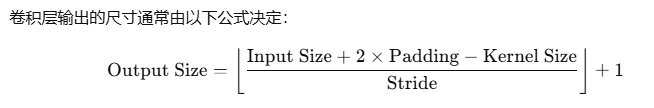

## LowPassModule

In [3]:
import torch
from torch import einsum, nn
import torch.nn.functional as F
import torch.nn as nn
from functools import partial
import math
import numpy as np
from einops import rearrange

# 通过低通滤波器的方式进行特征提取
class LowPassModule(nn.Module):
    def __init__(self, in_channel, sizes=(1, 2, 3, 6)):
        # 低通滤波器的不同尺寸，可以通过不同的滤波器尺寸进行处理，大小分别为1x1，2x2，3x3和6x6。
        super().__init__()
        self.stages = []
        self.stages = nn.ModuleList([self._make_stage(size) for size in sizes])
        # 为每种大小创建一个滤波器（使用 nn.AdaptiveAvgPool2d 进行池化），以适应输入特征图的大小。
        self.relu = nn.ReLU()
        ch =  in_channel // 4
        self.channel_splits = [ch, ch, ch, ch]
        # 将输入特征图的通道分为四部分，每个部分的通道数是 in_channel // 4
    def _make_stage(self, size):
        prior = nn.AdaptiveAvgPool2d(output_size=(size, size))
        return nn.Sequential(prior)

    def forward(self, feats):
        h, w = feats.size(2), feats.size(3) # 获取输入特征图的高度和宽度
        feats = torch.split(feats, self.channel_splits, dim=1) # 将输入的 feats 按照 self.channel_splits 划分成多个部分
        for feat in feats:
            print(feat.shape) # 将上采样后的部分乘以 0.5
        for i in range(4):
            input  = self.stages[i](feats[i])
            print('###',input.shape) # 将上采样后的部分乘以 0.5
        priors = [F.upsample(input=self.stages[i](feats[i]), size=(h, w), mode='bilinear') for i in range(4)] # 对每个部分应用 stages[i]，即进行自适应池化后，再通过双线性插值将其上采样至输入图像的原始大小。
        for prior in priors:
            print(prior.shape) # 将上采样后的部分乘以 0.5
        bottle = torch.cat(priors, 1) # 将所有上采样后的部分沿着通道维度拼接。
        
        return self.relu(bottle)
    
# Define random input data
B, h, N, Ch = 2, 4, 16, 64  # Batch size, number of heads, spatial size, channel size
q = torch.randn(B, h, N, Ch)  # Query tensor
v = torch.randn(B, h, N, Ch)  # Value tensor
size = (4, 4)  # Target output size for the convolution
H, W = size

v_img = rearrange(v, "B h (H W) Ch -> B (h Ch) H W", H=H, W=W)
print(v_img.shape)
# LowPassModule test
low_pass_module = LowPassModule(in_channel=64*4)
low_pass_output = low_pass_module(v_img)  # Test LowPassModule
print(low_pass_output.shape)

torch.Size([2, 256, 4, 4])
torch.Size([2, 64, 4, 4])
torch.Size([2, 64, 4, 4])
torch.Size([2, 64, 4, 4])
torch.Size([2, 64, 4, 4])
### torch.Size([2, 64, 1, 1])
### torch.Size([2, 64, 2, 2])
### torch.Size([2, 64, 3, 3])
### torch.Size([2, 64, 6, 6])
torch.Size([2, 64, 4, 4])
torch.Size([2, 64, 4, 4])
torch.Size([2, 64, 4, 4])
torch.Size([2, 64, 4, 4])
torch.Size([2, 256, 4, 4])


/data2/tongshuo/.local/lib/python3.8/site-packages/torch/nn/functional.py:3737: UserWarning: nn.functional.upsample is deprecated. Use nn.functional.interpolate instead.
  warnings.warn("nn.functional.upsample is deprecated. Use nn.functional.interpolate instead.")


In [7]:
# Define random input data
B, h, N, Ch = 2, 4, 16, 64  # Batch size, number of heads, spatial size, channel size
q = torch.randn(B, h, N, Ch)  # Query tensor
v = torch.randn(B, h, N, Ch)  # Value tensor
size = (4, 4)  # Target output size for the convolution
H, W = size

v_img = rearrange(v, "B h (H W) Ch -> B (h Ch) H W", H=H, W=W)
print(v_img.shape)
# LowPassModule test
low_pass_module = LowPassModule(in_channel=64*4)
low_pass_output = low_pass_module(v_img)  # Test LowPassModule
print(low_pass_output.shape)

torch.Size([2, 256, 4, 4])
torch.Size([2, 256, 4, 4])


/data2/tongshuo/.local/lib/python3.8/site-packages/torch/nn/functional.py:3737: UserWarning: nn.functional.upsample is deprecated. Use nn.functional.interpolate instead.
  warnings.warn("nn.functional.upsample is deprecated. Use nn.functional.interpolate instead.")


## AddNormModule

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class AddNormModule(nn.Module):
    def __init__(self, in_channel, kernel_size=3, stride=1, sizes=(1, 2, 3, 6)):
        super().__init__()
        
        # 低通滤波器部分
        self.low_pass = LowPassModule(in_channel=in_channel, sizes=sizes)
        
        # 自适应卷积部分：带有步幅的卷积
        self.strided_conv = nn.Conv2d(
            in_channel, in_channel, kernel_size=kernel_size, stride=stride, padding=kernel_size // 2
        )
        
        # 归一化操作：可以选择 LayerNorm 或 BatchNorm
        self.norm = nn.LayerNorm(in_channel)

    def forward(self, feats):
        # 低通滤波器处理
        low_pass_feats = self.low_pass(feats)
        
        # 自适应卷积处理
        strided_feats = self.strided_conv(feats)
        print(low_pass_feats.shape, strided_feats.shape)
        # 进行加法操作
        fused_feats = low_pass_feats + strided_feats
        
        # 归一化
        fused_feats = self.norm(fused_feats.flatten(2).transpose(1, 2)).transpose(1, 2).reshape_as(fused_feats)
        
        return fused_feats
# 定义测试数据
B, C, H, W = 2, 64, 8, 8  # Batch size, Channels, Height, Width
feats = torch.randn(B, C, H, W)  # 随机生成一个图像特征张量

# 实例化 AddNormModule
add_norm_module = AddNormModule(in_channel=C)

# 通过 AddNormModule 进行前向传播
output = add_norm_module(feats)

# 打印输出的形状
print("Output Shape:", output.shape)


torch.Size([2, 64, 8, 8]) torch.Size([2, 64, 8, 8])
Output Shape: torch.Size([2, 64, 8, 8])


## add & norm操作

In [30]:
class Conv2d_BN(nn.Module):
    """Convolution with BN module."""

    def __init__(
            self,
            in_ch,
            out_ch,
            kernel_size=1,
            stride=1,
            pad=0,
            dilation=1,
            groups=1,
            bn_weight_init=1,
            norm_layer=nn.BatchNorm2d,
            act_layer=None,
    ):
        super().__init__()

        self.conv = torch.nn.Conv2d(in_ch,
                                    out_ch,
                                    kernel_size,
                                    stride,
                                    pad,
                                    dilation,
                                    groups,
                                    bias=False)
        self.bn = norm_layer(out_ch) # 批归一化层
        torch.nn.init.constant_(self.bn.weight, bn_weight_init)
        torch.nn.init.constant_(self.bn.bias, 0)
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                # Note that there is no bias due to BN
                fan_out = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
                m.weight.data.normal_(mean=0.0, std=np.sqrt(2.0 / fan_out))

        self.act_layer = act_layer() if act_layer is not None else nn.Identity(
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.act_layer(x)

        return x
    
aggregate = Conv2d_BN(256, 128, act_layer=nn.Hardswish)

batch_size = 8  # 批大小
input_data = torch.randn(batch_size, 256, 32, 32)  # 随机生成数据，大小为 (8, 256, 32, 32)
# 将生成的数据传入网络
output = aggregate(input_data)

# 输出结果的尺寸
print(f"输入数据的尺寸: {input_data.shape}")
print(f"输出数据的尺寸: {output.shape}")

输入数据的尺寸: torch.Size([8, 256, 32, 32])
输出数据的尺寸: torch.Size([8, 128, 32, 32])


## 深度可分离卷积

In [13]:
# 深度可分离卷积
class SepConv(nn.Module):
    def __init__(self, channel_in, channel_out, kernel_size=3, stride=2, padding=1, affine=True):
        #   depthwise and pointwise convolution, downsample by 2
        # groups=channel_in：设置 groups=channel_in 使得每个输入通道与一个独立的卷积核进行卷积（深度卷积），每个通道都有自己的卷积核，不进行通道之间的混合。
        super(SepConv, self).__init__()
        self.op = nn.Sequential(
            # 执行深度卷积（Depthwise Convolution）
            nn.Conv2d(channel_in, channel_in, kernel_size=kernel_size, stride=stride, padding=padding,
                      groups=channel_in, bias=False),
            # 是逐点卷积（Pointwise Convolution）。它使用 1×1 卷积核对每个通道的输出进行卷积，以实现通道之间的混合，改变特征图的通道数。
            nn.Conv2d(channel_in, channel_in, kernel_size=1, padding=0, bias=False),
            # 批量归一化层（BatchNorm2d）。它的作用是对每个通道进行标准化，
            nn.BatchNorm2d(channel_in, affine=affine),
            nn.ReLU(inplace=False),
            # 第三个卷积层，执行深度卷积（Depthwise Convolution）。这个层与第一个卷积层相似，但步幅是 1，没有进行下采样。这样可以保留特征图的空间尺寸。
            nn.Conv2d(channel_in, channel_in, kernel_size=kernel_size, stride=1, padding=padding, groups=channel_in,
                      bias=False),
            # 第四个卷积层，使用 1×1 的卷积核进行逐点卷积，将通道数从 channel_in 转换到 channel_out，即生成最终的输出通道数。
            nn.Conv2d(channel_in, channel_out, kernel_size=1, padding=0, bias=False),
            nn.BatchNorm2d(channel_out, affine=affine),
            nn.ReLU(inplace=False),
        )

    def forward(self, x):
        return self.op(x)
    

# 创建 SepConv 实例，假设输入通道为 3，输出通道为 16，使用 3x3 的卷积核，步幅为 2，填充为 1
sepconv = SepConv(channel_in=3, channel_out=16, kernel_size=3, stride=2, padding=1)

# 生成测试数据，假设批量大小为 4，输入图像大小为 3x224x224
input_data = torch.randn(4, 3, 224, 224)  # 批量大小 4，3 通道，224x224 高度和宽度

# 通过 SepConv 模块进行前向传播
output_data = sepconv(input_data)

# 打印输出的形状
print("Output shape:", output_data.shape)


Output shape: torch.Size([4, 16, 112, 112])


In [9]:
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F

# 通过低通滤波器的方式进行特征提取
class LowPassModule(nn.Module):
    def __init__(self, in_channel, sizes=(1, 2, 3, 6)):
        # 低通滤波器的不同尺寸，可以通过不同的滤波器尺寸进行处理，大小分别为1x1，2x2，3x3和6x6。
        super().__init__()
        self.stages = []
        self.stages = nn.ModuleList([self._make_stage(size) for size in sizes])
        # 为每种大小创建一个滤波器（使用 nn.AdaptiveAvgPool2d 进行池化），以适应输入特征图的大小。
        self.relu = nn.ReLU()
        ch =  in_channel // 4
        self.channel_splits = [ch, ch, ch, ch]
        # 将输入特征图的通道分为四部分，每个部分的通道数是 in_channel // 4
    def _make_stage(self, size):
        prior = nn.AdaptiveAvgPool2d(output_size=(size, size))
        return nn.Sequential(prior)

    def forward(self, feats):
        h, w = feats.size(2), feats.size(3) # 获取输入特征图的高度和宽度
        feats = torch.split(feats, self.channel_splits, dim=1) # 将输入的 feats 按照 self.channel_splits 划分成多个部分
        priors = [F.upsample(input=self.stages[i](feats[i]), size=(h, w), mode='bilinear') for i in range(4)] # 对每个部分应用 stages[i]，即进行自适应池化后，再通过双线性插值将其上采样至输入图像的原始大小。
        bottle = torch.cat(priors, 1) # 将所有上采样后的部分沿着通道维度拼接。
        
        return self.relu(bottle)

class Conv2d_BN(nn.Module):
    """Convolution with BN module."""

    def __init__(
            self,
            in_ch,
            out_ch,
            kernel_size=1,
            stride=1,
            pad=0,
            dilation=1,
            groups=1,
            bn_weight_init=1,
            norm_layer=nn.BatchNorm2d,
            act_layer=None,
    ):
        super().__init__()

        self.conv = torch.nn.Conv2d(in_ch,
                                    out_ch,
                                    kernel_size,
                                    stride,
                                    pad,
                                    dilation,
                                    groups,
                                    bias=False)
        self.bn = norm_layer(out_ch) # 批归一化层
        torch.nn.init.constant_(self.bn.weight, bn_weight_init)
        torch.nn.init.constant_(self.bn.bias, 0)
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                # Note that there is no bias due to BN
                fan_out = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
                m.weight.data.normal_(mean=0.0, std=np.sqrt(2.0 / fan_out))

        self.act_layer = act_layer() if act_layer is not None else nn.Identity(
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.act_layer(x)

        return x

# 深度可分离卷积
class SepConv(nn.Module):
    def __init__(self, channel_in, channel_out, kernel_size=3, stride=2, padding=1, affine=True):
        #   depthwise and pointwise convolution, downsample by 2
        # groups=channel_in：设置 groups=channel_in 使得每个输入通道与一个独立的卷积核进行卷积（深度卷积），每个通道都有自己的卷积核，不进行通道之间的混合。
        super(SepConv, self).__init__()
        self.op = nn.Sequential(
            # 执行深度卷积（Depthwise Convolution）
            nn.Conv2d(channel_in, channel_in, kernel_size=kernel_size, stride=stride, padding=padding,
                      groups=channel_in, bias=False),
            # 是逐点卷积（Pointwise Convolution）。它使用 1×1 卷积核对每个通道的输出进行卷积，以实现通道之间的混合，改变特征图的通道数。
            nn.Conv2d(channel_in, channel_in, kernel_size=1, padding=0, bias=False),
            # 批量归一化层（BatchNorm2d）。它的作用是对每个通道进行标准化，
            nn.BatchNorm2d(channel_in, affine=affine),
            nn.ReLU(inplace=False),
            # 第三个卷积层，执行深度卷积（Depthwise Convolution）。这个层与第一个卷积层相似，但步幅是 1，没有进行下采样。这样可以保留特征图的空间尺寸。
            nn.Conv2d(channel_in, channel_in, kernel_size=kernel_size, stride=1, padding=padding, groups=channel_in,
                      bias=False),
            # 第四个卷积层，使用 1×1 的卷积核进行逐点卷积，将通道数从 channel_in 转换到 channel_out，即生成最终的输出通道数。
            nn.Conv2d(channel_in, channel_out, kernel_size=1, padding=0, bias=False),
            nn.BatchNorm2d(channel_out, affine=affine),
            nn.ReLU(inplace=False),
        )

    def forward(self, x):
        return self.op(x)

class StuLowPassModule(nn.Module):
    def __init__(self, in_channel, kernel_size=3, stride = 1, sizes=(1, 2, 3, 6)):
        super().__init__()

        # 低通滤波器的卷积部分，保证和自适应卷积的大小一致
        self.conv = nn.Conv2d(in_channel, in_channel, kernel_size=kernel_size, stride=stride, padding=1)
        # 低通滤波器部分
        self.low_pass = LowPassModule(in_channel=in_channel, sizes=sizes)
        # 修改后的自适应卷积部分：步幅和卷积核大小为 s x s
        self.strided_conv = nn.Conv2d(
            in_channel, in_channel, kernel_size=kernel_size, stride=stride, padding=1
        )
        
        # 归一化操作：使用 LayerNorm
        self.aggregate = Conv2d_BN(in_channel*2, in_channel, act_layer=nn.Hardswish)
        
        # 深度分离卷积操作：使用 SepConv
        self.sepconv = SepConv(channel_in=in_channel, channel_out=in_channel, kernel_size=3, stride=1, padding=1)

    def forward(self, feats):
        print('input shape:', feats.shape)
        # 低通滤波器处理
        feats_1 = self.conv(feats)
        print("conv1 Shape:", feats_1.shape)
        # 低通滤波器处理
        low_pass_feats = self.low_pass(feats_1)
        print("low pass feats Shape:", low_pass_feats.shape)
        # 自适应卷积处理
        strided_feats = self.strided_conv(feats)
        print("Strided Feats Shape:", strided_feats.shape)
        # 进行拼接操作
        fused_feats = torch.cat((low_pass_feats, strided_feats), dim=1)
        print("Fused Feats Shape:", fused_feats.shape)
        # 聚合加归一化
        out_feats = self.aggregate(fused_feats)
        print('add & norm_out_feats:', out_feats.shape)
        # 深度可分离卷积
        out_feats = self.sepconv(out_feats)
        print('sepconv:', out_feats.shape)
        return out_feats
# 定义测试数据
B, C, H, W = 2, 64, 8, 8  # Batch size, Channels, Height, Width
feats = torch.randn(B, C, H, W)  # 随机生成一个图像特征张量

# 实例化 StuLowPassModule
stu_low_module = StuLowPassModule(in_channel=C, kernel_size=3, stride=1)  # 使用 3x3 的卷积核和步幅                                                                                       

# 通过 StuLowPassModule 进行前向传播
output = stu_low_module(feats)

input shape: torch.Size([2, 64, 8, 8])
conv1 Shape: torch.Size([2, 64, 8, 8])
low pass feats Shape: torch.Size([2, 64, 8, 8])
Strided Feats Shape: torch.Size([2, 64, 8, 8])
Fused Feats Shape: torch.Size([2, 128, 8, 8])
add & norm_out_feats: torch.Size([2, 64, 8, 8])
sepconv: torch.Size([2, 64, 8, 8])


/data2/tongshuo/.local/lib/python3.8/site-packages/torch/nn/functional.py:3737: UserWarning: nn.functional.upsample is deprecated. Use nn.functional.interpolate instead.
  warnings.warn("nn.functional.upsample is deprecated. Use nn.functional.interpolate instead.")


In [5]:
class SepConv(nn.Module):
    def __init__(self, channel_in, channel_out, kernel_size=3, stride=2, padding=1, affine=True):
        #   depthwise and pointwise convolution, downsample by 2
        # groups=channel_in：设置 groups=channel_in 使得每个输入通道与一个独立的卷积核进行卷积（深度卷积），每个通道都有自己的卷积核，不进行通道之间的混合。
        super(SepConv, self).__init__()
        self.op = nn.Sequential(
            # 执行深度卷积（Depthwise Convolution）
            nn.Conv2d(channel_in, channel_in, kernel_size=kernel_size, stride=stride, padding=padding,
                      groups=channel_in, bias=False),
            # 是逐点卷积（Pointwise Convolution）。它使用 1×1 卷积核对每个通道的输出进行卷积，以实现通道之间的混合，改变特征图的通道数。
            nn.Conv2d(channel_in, channel_in, kernel_size=1, padding=0, bias=False),
            # 批量归一化层（BatchNorm2d）。它的作用是对每个通道进行标准化，
            nn.BatchNorm2d(channel_in, affine=affine),
            nn.ReLU(inplace=False),
            # 第三个卷积层，执行深度卷积（Depthwise Convolution）。这个层与第一个卷积层相似，但步幅是 1，没有进行下采样。这样可以保留特征图的空间尺寸。
            nn.Conv2d(channel_in, channel_in, kernel_size=kernel_size, stride=1, padding=padding, groups=channel_in,
                      bias=False),
            # 第四个卷积层，使用 1×1 的卷积核进行逐点卷积，将通道数从 channel_in 转换到 channel_out，即生成最终的输出通道数。
            nn.Conv2d(channel_in, channel_out, kernel_size=1, padding=0, bias=False),
            nn.BatchNorm2d(channel_out, affine=affine),
            nn.ReLU(inplace=False),
        )

    def forward(self, x):
        return self.op(x)


# 通过低通滤波器的方式进行特征提取
class SPPModule(nn.Module):
    def __init__(self, in_channels, sizes=(1, 2, 3, 6)):
        # 低通滤波器的不同尺寸，可以通过不同的滤波器尺寸进行处理，大小分别为1x1，2x2，3x3和6x6。
        super(SPPModule, self).__init__()
        self.stages = []
        self.stages = nn.ModuleList([self._make_stage(size) for size in sizes])
        # 为每种大小创建一个滤波器（使用 nn.AdaptiveAvgPool2d 进行池化），以适应输入特征图的大小。
        # self.relu = nn.ReLU()
        self.sepconv = SepConv(channel_in=in_channels, channel_out=in_channels, kernel_size=3, stride=1, padding=1)

    def _make_stage(self, size):
        prior = nn.AdaptiveAvgPool2d(output_size=(size, size))
        return nn.Sequential(prior)

    def forward(self, feats):
        h, w = feats.size(2), feats.size(3) # 获取输入特征图的高度和宽度
        # priors = [self.stages[i](feats) for i in range(4)]
        priors = [F.upsample(input=self.stages[i](feats), size=(h, w), mode='bilinear') for i in range(4)] # 对每个部分应用 stages[i]，即进行自适应池化后，再通过双线性插值将其上采样至输入图像的原始大小。
        bottle = torch.cat(priors, 1) # 将所有上采样后的部分沿着通道维度拼接。
        out_feats = self.sepconv(bottle)
        # priors = [F.upsample(input=self.stages[i](feats[i]), size=(h, w), mode='bilinear') for i in range(4)] # 对每个部分应用 stages[i]，即进行自适应池化后，再通过双线性插值将其上采样至输入图像的原始大小。
        # bottle = torch.cat(priors, 1) # 将所有上采样后的部分沿着通道维度拼接。
        # for i in range(len(priors)):
        #     priors[i] = torch.flatten(priors[i], start_dim=2, end_dim=3)  # B X C X feature_num
        # merged_tensor = torch.cat(priors, dim=2).unsqueeze(-1)
        # out_feats = self.sepconv(merged_tensor).squeeze()
        return out_feats

feat1 = torch.randn([8, 64, 56, 56])
# feat2 = torch.randn([8, 256, 56, 56])
spp = SPPModule(in_channels=64*4)
priors = spp(feat1)
print(priors.shape)
# priors = spp(feat2)
# print(priors.shape)
# for prior in priors:
#     print(prior.shape)

torch.Size([8, 256, 56, 56])


In [8]:
class SPP(nn.Module):
    def __init__(self, M=None):
        super(SPP, self).__init__()
        self.pooling_4x4 = nn.AdaptiveAvgPool2d((4, 4))
        self.pooling_2x2 = nn.AdaptiveAvgPool2d((2, 2))
        self.pooling_1x1 = nn.AdaptiveAvgPool2d((1, 1))

        self.M = M
        print(self.M)

    def forward(self, x):
        # print('输入', x.shape) # [8, 512, 7, 7]
        x_4x4 = self.pooling_4x4(x) # [8, 512, 4, 4]
        x_2x2 = self.pooling_2x2(x_4x4) # [8, 512, 2, 2]
        x_1x1 = self.pooling_1x1(x_4x4) # [8, 512, 1, 1]

        x_4x4_flatten = torch.flatten(x_4x4, start_dim=2, end_dim=3)  # B X C X feature_num
        # print('444##################', x_4x4_flatten.shape)
        x_2x2_flatten = torch.flatten(x_2x2, start_dim=2, end_dim=3)
        # print('222##################', x_2x2_flatten.shape)
        x_1x1_flatten = torch.flatten(x_1x1, start_dim=2, end_dim=3)
        # print('111##################', x_1x1_flatten.shape)
        if self.M == '[1,2,4]':
            x_feature = torch.cat((x_1x1_flatten, x_2x2_flatten, x_4x4_flatten), dim=2)
        elif self.M == '[1,2]':
            x_feature = torch.cat((x_1x1_flatten, x_2x2_flatten), dim=2)
        else:
            raise NotImplementedError('ERROR M')

        print('cat###########', x_feature.shape) # [8, 512, 21]
        x_strength = x_feature.permute((2, 0, 1))
        x_strength = torch.mean(x_strength, dim=2)


        return x_feature, x_strength

In [9]:
spp = SPP(M="[1,2,4]")
num_classes = 5
fc = nn.Linear(512, 5)
feat4 = torch.randn([8, 512, 7, 7])

feat4 = F.relu(feat4)
print('feat4 shape:', feat4.shape) # [8, 2048, 7, 7] / [8, 512, 7, 7]
x_spp, x_strength = spp(feat4)
print('x_spp shape:', x_spp.shape) # [8, 2048, 21] / [8, 512, 21]

x_spp = x_spp.permute((2, 0, 1))
print('2x_spp shape:', x_spp.shape) # [21, 8, 2048] / [21, 8, 512]
m, b, c = x_spp.shape[0], x_spp.shape[1], x_spp.shape[2]
print('m, b, c:', m, b, c) # 21 8 2048 / 21 8 512
x_spp = torch.reshape(x_spp, (m * b, c))
print('3x_spp shape:', x_spp.shape) # [168, 2048] / [168, 512]
patch_score = fc(x_spp)
print('patch_score shape:', patch_score.shape) # [168, 5] / [168, 5]
patch_score = torch.reshape(patch_score, (m, b, num_classes))
print('patch_score shape:', patch_score.shape) # [21, 8, 5] / [21, 8, 5]
patch_score = patch_score.permute((1, 2, 0)) # [8, 5, 21] / [8, 5, 21]

[1,2,4]
feat4 shape: torch.Size([8, 512, 7, 7])
输入 torch.Size([8, 512, 7, 7])
x_4x4 torch.Size([8, 512, 4, 4])
x_2x2 torch.Size([8, 512, 2, 2])
x_1x1 torch.Size([8, 512, 1, 1])
444################## torch.Size([8, 512, 16])
222################## torch.Size([8, 512, 4])
111################## torch.Size([8, 512, 1])
cat########### torch.Size([8, 512, 21])
x_spp shape: torch.Size([8, 512, 21])
2x_spp shape: torch.Size([21, 8, 512])
m, b, c: 21 8 512
3x_spp shape: torch.Size([168, 512])
patch_score shape: torch.Size([168, 5])
patch_score shape: torch.Size([21, 8, 5])


## 下面这种做法相当于进行了不同尺度的浅层特征提取，但是用一个深度可分离卷积把channels从4*C—>C

In [ ]:
class SPPModule(nn.Module):
    def __init__(self, in_channels, sizes=(1, 2, 3, 6)):
        # 低通滤波器的不同尺寸，可以通过不同的滤波器尺寸进行处理，大小分别为1x1，2x2，3x3和6x6。
        super(SPPModule, self).__init__()
        self.stages = []
        self.stages = nn.ModuleList([self._make_stage(size) for size in sizes])
        self.sepconv = SepConv(channel_in=in_channels*4, channel_out=in_channels, kernel_size=3, stride=1, padding=1)

    def _make_stage(self, size):
        prior = nn.AdaptiveAvgPool2d(output_size=(size, size))
        return nn.Sequential(prior)

    def forward(self, feats):
        h, w = feats.size(2), feats.size(3) # 获取输入特征图的高度和宽度
        priors = [F.upsample(input=self.stages[i](feats), size=(h, w), mode='bilinear') for i in range(4)] # 对每个部分应用 stages[i]，即进行自适应池化后，再通过双线性插值将其上采样至输入图像的原始大小。
        bottle = torch.cat(priors, 1) # 将所有上采样后的部分沿着通道维度拼接。
        out_feats = self.sepconv(bottle)
        return out_feats
    

## 教师模型输出几种不同尺度的特征，不做上采样

In [14]:
import torch
from torch import einsum, nn
import torch.nn.functional as F
import torch.nn as nn
from functools import partial
import math
import numpy as np
from einops import rearrange

# 通过低通滤波器的方式教师的前层特征进行多尺度特征提取
class SPP_bil_LPModule(nn.Module):
    def __init__(self, sizes=(1, 2, 3, 6)):
        # 低通滤波器的不同尺寸，可以通过不同的滤波器尺寸进行处理，大小分别为1x1，2x2，3x3和6x6。
        super().__init__()
        self.stages = []
        self.stages = nn.ModuleList([self._make_stage(size) for size in sizes])
        # 为每种大小创建一个滤波器（使用 nn.AdaptiveAvgPool2d 进行池化），以适应输入特征图的大小。
        self.relu = nn.ReLU()
    def _make_stage(self, size):
        prior = nn.AdaptiveAvgPool2d(output_size=(size, size))
        return nn.Sequential(prior)

    def forward(self, feats):
        h, w = feats.size(2), feats.size(3) # 获取输入特征图的高度和宽度
        priors = [F.upsample(input=self.stages[i](feats), size=(h, w), mode='bilinear') for i in range(4)] # 对每个部分应用 stages[i]，即进行自适应池化后，再通过双线性插值将其上采样至输入图像的原始大小。
        # priors = [self.stages[i](feats) for i in range(4)]
        return self.relu(priors[0]), self.relu(priors[1]), self.relu(priors[2]), self.relu(priors[3]) # 返回四个不同池化尺度的部分
    
# Define random input data
B, h, N, Ch = 2, 4, 16, 64  # Batch size, number of heads, spatial size, channel size
q = torch.randn(B, h, N, Ch)  # Query tensor
v = torch.randn(B, h, N, Ch)  # Value tensor
size = (4, 4)  # Target output size for the convolution
H, W = size

v_img = rearrange(v, "B h (H W) Ch -> B (h Ch) H W", H=H, W=W)
print(v_img.shape)
# LowPassModule test
low_pass_module = SPP_bil_LPModule()
low_pass_output_1, low_pass_output_2, low_pass_output_3, low_pass_output_6 = low_pass_module(v_img)  # Test LowPassModule
print(low_pass_output_1.shape, low_pass_output_2.shape, low_pass_output_3.shape, low_pass_output_6.shape)   

torch.Size([2, 256, 4, 4])
torch.Size([2, 256, 4, 4]) torch.Size([2, 256, 4, 4]) torch.Size([2, 256, 4, 4]) torch.Size([2, 256, 4, 4])


/data2/tongshuo/.local/lib/python3.8/site-packages/torch/nn/functional.py:3737: UserWarning: nn.functional.upsample is deprecated. Use nn.functional.interpolate instead.
  warnings.warn("nn.functional.upsample is deprecated. Use nn.functional.interpolate instead.")


## 学生模型输出几种不同尺度的特征  
### 做了几种尝试，首先是有没有池化前的conv操作
### 其次是有没有上采样的过程  
### 发现双线性插值的上采样过程是最占显存的

In [15]:
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F

# 通过低通滤波器的方式进行特征提取
class LowPassModule(nn.Module):
    def __init__(self, in_channel, sizes=(1, 2, 3, 6)):
        # 低通滤波器的不同尺寸，可以通过不同的滤波器尺寸进行处理，大小分别为1x1，2x2，3x3和6x6。
        super().__init__()
        self.stages = []
        self.stages = nn.ModuleList([self._make_stage(size) for size in sizes])
        # 为每种大小创建一个滤波器（使用 nn.AdaptiveAvgPool2d 进行池化），以适应输入特征图的大小。
        self.relu = nn.ReLU()
        ch =  in_channel // 4
        self.channel_splits = [ch, ch, ch, ch]
        # 将输入特征图的通道分为四部分，每个部分的通道数是 in_channel // 4
    def _make_stage(self, size):
        prior = nn.AdaptiveAvgPool2d(output_size=(size, size))
        return nn.Sequential(prior)

    def forward(self, feats):
        h, w = feats.size(2), feats.size(3) # 获取输入特征图的高度和宽度
        feats = torch.split(feats, self.channel_splits, dim=1) # 将输入的 feats 按照 self.channel_splits 划分成多个部分
        priors = [F.upsample(input=self.stages[i](feats[i]), size=(h, w), mode='bilinear') for i in range(4)] # 对每个部分应用 stages[i]，即进行自适应池化后，再通过双线性插值将其上采样至输入图像的原始大小。
        bottle = torch.cat(priors, 1) # 将所有上采样后的部分沿着通道维度拼接。
        
        return self.relu(bottle)

class SPP_LPModule(nn.Module):
    def __init__(self, sizes=(1, 2, 3, 6)):
        # 低通滤波器的不同尺寸，可以通过不同的滤波器尺寸进行处理，大小分别为1x1，2x2，3x3和6x6。
        super().__init__()
        self.stages = []
        self.stages = nn.ModuleList([self._make_stage(size) for size in sizes])
        # 为每种大小创建一个滤波器（使用 nn.AdaptiveAvgPool2d 进行池化），以适应输入特征图的大小。
        self.relu = nn.ReLU()
    def _make_stage(self, size):
        prior = nn.AdaptiveAvgPool2d(output_size=(size, size))
        return nn.Sequential(prior)

    def forward(self, feats):
        # priors = [self.stages[i](feats) for i in range(4)]
        h, w = feats.size(2), feats.size(3) # 获取输入特征图的高度和宽度
        priors = [F.upsample(input=self.stages[i](feats), size=(h, w), mode='bilinear') for i in range(4)] # 对每个部分应用 stages[i]，即进行自适应池化后，再通过双线性插值将其上采样至输入图像的原始大小。
        return self.relu(priors[0]), self.relu(priors[1]), self.relu(priors[2]), self.relu(priors[3]) # 返回四个不同池化尺度的部分


class Conv2d_BN(nn.Module):
    """Convolution with BN module."""

    def __init__(
            self,
            in_ch,
            out_ch,
            kernel_size=1,
            stride=1,
            pad=0,
            dilation=1,
            groups=1,
            bn_weight_init=1,
            norm_layer=nn.BatchNorm2d,
            act_layer=None,
    ):
        super().__init__()

        self.conv = torch.nn.Conv2d(in_ch,
                                    out_ch,
                                    kernel_size,
                                    stride,
                                    pad,
                                    dilation,
                                    groups,
                                    bias=False)
        self.bn = norm_layer(out_ch) # 批归一化层
        torch.nn.init.constant_(self.bn.weight, bn_weight_init)
        torch.nn.init.constant_(self.bn.bias, 0)
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                # Note that there is no bias due to BN
                fan_out = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
                m.weight.data.normal_(mean=0.0, std=np.sqrt(2.0 / fan_out))

        self.act_layer = act_layer() if act_layer is not None else nn.Identity(
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.act_layer(x)

        return x

# 深度可分离卷积
class SepConv(nn.Module):
    def __init__(self, channel_in, channel_out, kernel_size=3, stride=2, padding=1, affine=True):
        #   depthwise and pointwise convolution, downsample by 2
        # groups=channel_in：设置 groups=channel_in 使得每个输入通道与一个独立的卷积核进行卷积（深度卷积），每个通道都有自己的卷积核，不进行通道之间的混合。
        super(SepConv, self).__init__()
        self.op = nn.Sequential(
            # 执行深度卷积（Depthwise Convolution）
            nn.Conv2d(channel_in, channel_in, kernel_size=kernel_size, stride=stride, padding=padding,
                      groups=channel_in, bias=False),
            # 是逐点卷积（Pointwise Convolution）。它使用 1×1 卷积核对每个通道的输出进行卷积，以实现通道之间的混合，改变特征图的通道数。
            nn.Conv2d(channel_in, channel_in, kernel_size=1, padding=0, bias=False),
            # 批量归一化层（BatchNorm2d）。它的作用是对每个通道进行标准化，
            nn.BatchNorm2d(channel_in, affine=affine),
            nn.ReLU(inplace=False),
            # 第三个卷积层，执行深度卷积（Depthwise Convolution）。这个层与第一个卷积层相似，但步幅是 1，没有进行下采样。这样可以保留特征图的空间尺寸。
            nn.Conv2d(channel_in, channel_in, kernel_size=kernel_size, stride=1, padding=padding, groups=channel_in,
                      bias=False),
            # 第四个卷积层，使用 1×1 的卷积核进行逐点卷积，将通道数从 channel_in 转换到 channel_out，即生成最终的输出通道数。
            nn.Conv2d(channel_in, channel_out, kernel_size=1, padding=0, bias=False),
            nn.BatchNorm2d(channel_out, affine=affine),
            nn.ReLU(inplace=False),
        )

    def forward(self, x):
        return self.op(x)

class StuSPPLowPassModule(nn.Module):
    def __init__(self, in_channel, kernel_size=3, stride = 1, sizes=(1, 2, 3, 6)):
        super().__init__()

        # 低通滤波器的卷积部分，保证和自适应卷积的大小一致
        self.conv = nn.Conv2d(in_channel, in_channel, kernel_size=kernel_size, stride=stride, padding=1)
        # 低通滤波器部分
        # self.low_pass = LowPassModule(in_channel=in_channel, sizes=sizes)
        self.low_pass = SPP_LPModule(sizes=sizes)
        # 修改后的自适应卷积部分：步幅和卷积核大小为 s x s
        # self.strided_conv = nn.Conv2d(
        #     in_channel, in_channel, kernel_size=kernel_size, stride=stride, padding=1
        # )
        
        # 归一化操作：使用 LayerNorm
        self.aggregate = Conv2d_BN(in_channel, in_channel, act_layer=nn.Hardswish)
        
        # 深度分离卷积操作：使用 SepConv
        self.sepconv = SepConv(channel_in=in_channel, channel_out=in_channel, kernel_size=3, stride=1, padding=1)

    def forward(self, feats):
        print('input shape:', feats.shape)
        # 低通滤波器处理
        feats = self.conv(feats)
        print("conv1 Shape:", feats.shape)
        # 低通滤波器处理
        low_pass_feats_1, low_pass_feats_2, low_pass_feats_3, low_pass_feats_6 = self.low_pass(feats_1)
        print("low pass feats Shape:", low_pass_feats_1.shape, low_pass_feats_2.shape, low_pass_feats_3.shape, low_pass_feats_6.shape)
        # 自适应卷积处理
        # strided_feats = self.strided_conv(feats)
        # print("Strided Feats Shape:", strided_feats.shape)
        # 进行拼接操作
        # fused_feats = torch.cat((low_pass_feats, strided_feats), dim=1)
        # print("Fused Feats Shape:", fused_feats.shape)
        # 聚合加归一化
        # out_feats = self.aggregate(fused_feats)
        # print('add & norm_out_feats:', out_feats.shape)
        # 深度可分离卷积
        # out_feats = self.sepconv(out_feats)
        low_pass_feats_1 = self.aggregate(low_pass_feats_1)
        low_pass_feats_2 = self.aggregate(low_pass_feats_2)
        low_pass_feats_3 = self.aggregate(low_pass_feats_3)
        low_pass_feats_6 = self.aggregate(low_pass_feats_6)

        low_pass_feats_1 = self.sepconv(low_pass_feats_1)
        low_pass_feats_2 = self.sepconv(low_pass_feats_2)
        low_pass_feats_3 = self.sepconv(low_pass_feats_3)
        low_pass_feats_6 = self.sepconv(low_pass_feats_6)
        return low_pass_feats_1, low_pass_feats_2, low_pass_feats_3, low_pass_feats_6
        # print('sepconv:', out_feats.shape)
        # return out_feats
# 定义测试数据
B, C, H, W = 2, 64, 8, 8  # Batch size, Channels, Height, Width
feats = torch.randn(B, C, H, W)  # 随机生成一个图像特征张量

# 实例化 StuLowPassModule
stu_low_module = StuLowPassModule(in_channel=C, kernel_size=3, stride=1)  # 使用 3x3 的卷积核和步幅                                                                                       

# 通过 StuLowPassModule 进行前向传播
a, b, c, d = stu_low_module(feats)
print(a.shape, b.shape, c.shape, d.shape)

input shape: torch.Size([2, 64, 8, 8])
conv1 Shape: torch.Size([2, 64, 8, 8])
low pass feats Shape: torch.Size([2, 64, 8, 8]) torch.Size([2, 64, 8, 8]) torch.Size([2, 64, 8, 8]) torch.Size([2, 64, 8, 8])
Strided Feats Shape: torch.Size([2, 64, 8, 8])
torch.Size([2, 64, 8, 8]) torch.Size([2, 64, 8, 8]) torch.Size([2, 64, 8, 8]) torch.Size([2, 64, 8, 8])
